In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
import os
print(os.listdir())


['.config', 'sample_data']


In [5]:
# Load Data
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# Data Overview

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

Shape: (8807, 12)

Columns:
 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing Values:

show_id            0
type               0
title              0
di

In [7]:
# Basic Cleaning

df = df.copy()

# Fill missing values
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Unknown")

# Convert date
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year
df['year_added'] = df['date_added'].dt.year

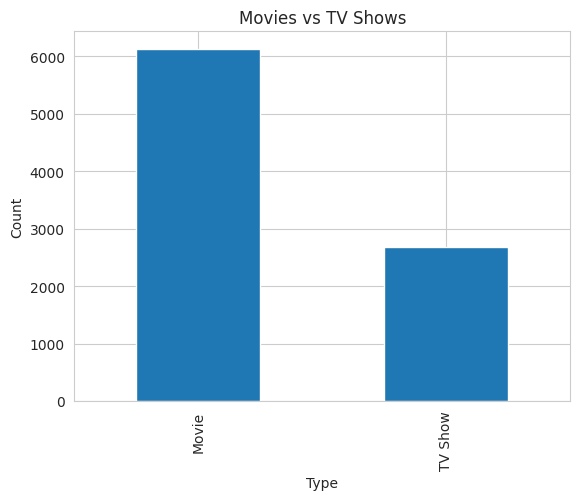

In [8]:
# Content Type Distribution

plt.figure()

df['type'].value_counts().plot(kind='bar')

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

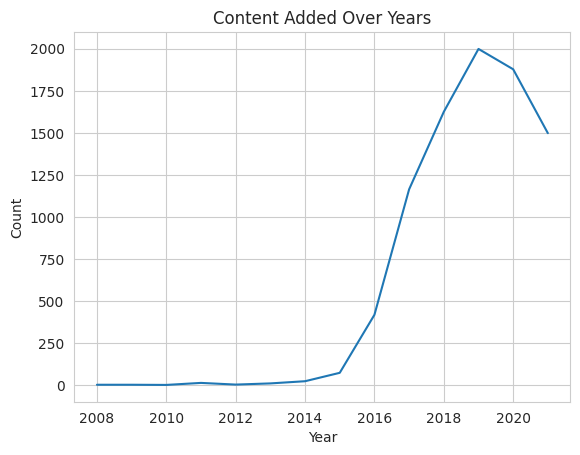

In [9]:
# Trend Over Years

plt.figure()

df['year_added'].value_counts().sort_index().plot()

plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

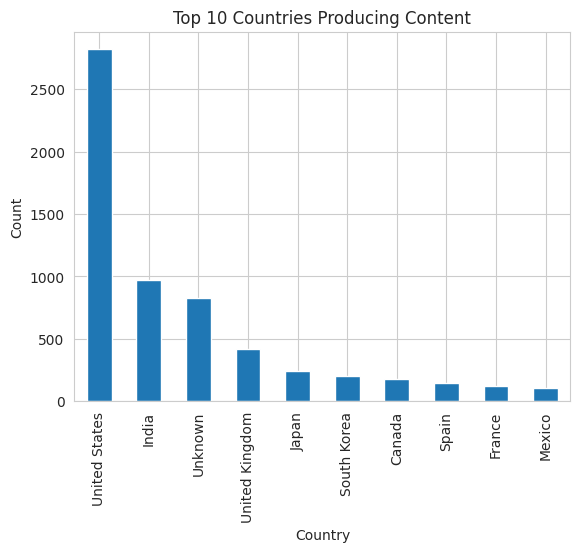

In [10]:
# Top Countries

top_countries = df['country'].value_counts().head(10)

plt.figure()

top_countries.plot(kind='bar')

plt.title("Top 10 Countries Producing Content")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

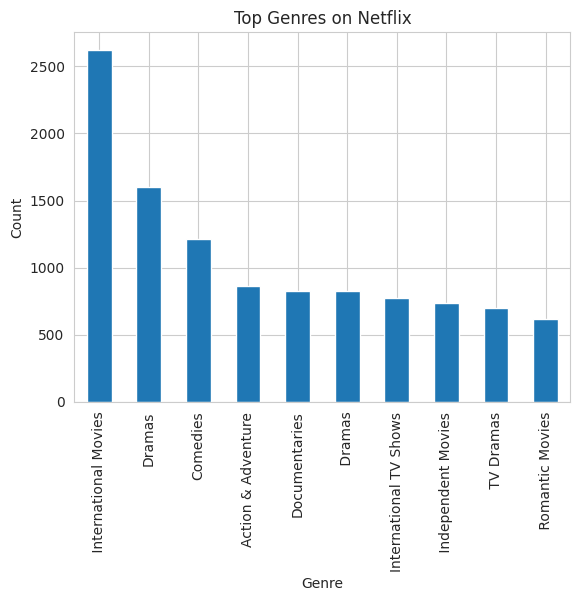

In [11]:
# Genre Analysis

# Split genres
df['listed_in'] = df['listed_in'].str.split(',')

# Explode
genre_df = df.explode('listed_in')

top_genres = genre_df['listed_in'].value_counts().head(10)

plt.figure()

top_genres.plot(kind='bar')

plt.title("Top Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()